NOTE: Correlation batata hai do numeric variables saath mein kaise move karte hain — +1 matlab perfect positive (ek badhe to doosra bhi badhe), -1 matlab perfect negative (ek badhe to doosra ghate), 0 matlab koi linear relation nahi. Day 25 mein NumPy se ek pair ka correlation dekha tha — aaj poori RFM table ka matrix banayenge.

1. Data load karo:

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/processed/customer_churn_labeled.csv')
print(df[['Recency', 'Frequency', 'Monetary', 'Churned']].head())

   Recency  Frequency  Monetary  Churned
0      325         12  77556.46        1
1        1          8   4921.53        0
2       74          5   2019.40        0
3       18          4   4428.69        0
4      309          1    334.40        1


2. Poora correlation matrix — .corr():

In [2]:
corr_matrix = df[['Recency', 'Frequency', 'Monetary', 'Churned']].corr()
print(corr_matrix.round(3))

           Recency  Frequency  Monetary  Churned
Recency      1.000     -0.257    -0.125    0.797
Frequency   -0.257      1.000     0.628   -0.253
Monetary    -0.125      0.628     1.000   -0.128
Churned      0.797     -0.253    -0.128    1.000


note: Diagonal hamesha 1.0 hoti hai (har variable apne aap se perfect correlated hota hai). Matrix symmetric hoti hai — Recency vs Frequency wahi value hai jo Frequency vs Recency.

3. .corr() ke methods — Pearson vs Spearman (bahut important fark):

In [3]:
pearson_corr = df[['Recency', 'Frequency', 'Monetary']].corr(method='pearson')
spearman_corr = df[['Recency', 'Frequency', 'Monetary']].corr(method='spearman')

print("Pearson:\n", pearson_corr.round(3))
print("\nSpearman:\n", spearman_corr.round(3))

Pearson:
            Recency  Frequency  Monetary
Recency      1.000     -0.257    -0.125
Frequency   -0.257      1.000     0.628
Monetary    -0.125      0.628     1.000

Spearman:
            Recency  Frequency  Monetary
Recency      1.000     -0.561    -0.511
Frequency   -0.561      1.000     0.858
Monetary    -0.511      0.858     1.000


Note: Pearson sirf linear relationship pakadta hai aur outliers se bahut affect hota hai. Spearman rank-based hai (values ko rank mein convert karke correlation nikalta hai) — yeh non-linear monotonic relationships bhi pakad leta hai aur outliers se kam affect hota hai. Day 42 mein tumne dekha tha Monetary bahut skewed hai, isliye yaha Spearman zyada reliable number dega.

4. Fark ka size dekho — kaunsa pair sabse zyada alag hai dono methods mein:

In [4]:
diff = (pearson_corr - spearman_corr).abs()
print(diff.round(3))

           Recency  Frequency  Monetary
Recency      0.000      0.304     0.386
Frequency    0.304      0.000     0.230
Monetary     0.386      0.230     0.000


Jahan fark bada hai, wahan outliers ya non-linear pattern ka shak karo.

5. Statistical significance bhi check karo (sirf number nahi, p-value bhi):

In [5]:
from scipy import stats

r, p = stats.pearsonr(df['Frequency'], df['Monetary'])
print(f"Pearson r = {r:.3f}, p-value = {p:.6f}")

rho, p_s = stats.spearmanr(df['Frequency'], df['Monetary'])
print(f"Spearman rho = {rho:.3f}, p-value = {p_s:.6f}")

Pearson r = 0.628, p-value = 0.000000
Spearman rho = 0.858, p-value = 0.000000


note: r/rho batata hai relationship ki strength aur direction; p-value batata hai ki yeh relationship chance se to nahi aa gaya (Day 44 ka concept yahan bhi lagta hai).

6. Heatmap se visualize karna (kal Matplotlib/Seaborn detail se seekhoge, aaj ek chhota preview):

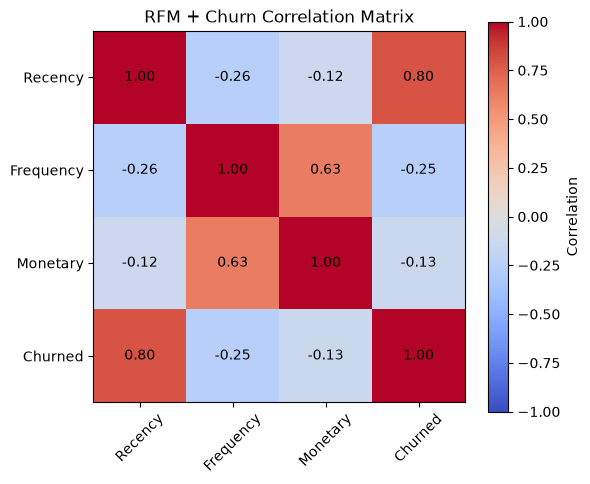

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr_matrix)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix)), corr_matrix.columns)
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        plt.text(j, i, f"{corr_matrix.iloc[i,j]:.2f}", ha='center', va='center')
plt.title('RFM + Churn Correlation Matrix')
plt.tight_layout()
plt.show()

7. Churned ke saath correlation — direct feature-importance ka ek chhota preview (Month 4 ke SHAP se connect karega):

In [7]:
churn_corr = df[['Recency', 'Frequency', 'Monetary']].corrwith(df['Churned'])
print(churn_corr.sort_values(key=abs, ascending=False))

Recency      0.796865
Frequency   -0.252791
Monetary    -0.128165
dtype: float64


Note: Recency ka Churned se correlation sabse zyada aayega — iska matlab hai multicollinearity ka risk, kyunki churn ki definition hi Recency par based hai (Day 43-46 mein isi baat ko highlight kiya tha). Yeh feature redundant/circular ho sakta hai model mein.

8. Scatter plot se non-linear pattern dekhna (correlation number kabhi gumraah kar sakta hai):

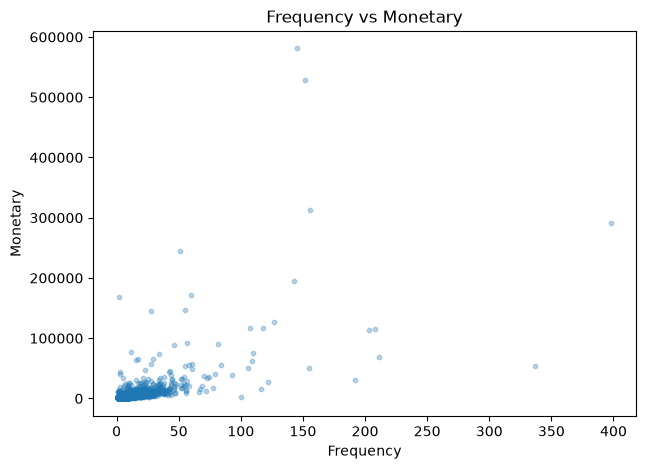

In [8]:
plt.figure(figsize=(7, 5))
plt.scatter(df['Frequency'], df['Monetary'], alpha=0.3, s=10)
plt.xlabel('Frequency')
plt.ylabel('Monetary')
plt.title('Frequency vs Monetary')
plt.show()

important note: Correlation sirf linear relationship measure karta hai. Agar scatter plot mein curve-jaisa (non-linear) pattern dikhe lekin correlation number chhota ho, iska matlab yeh nahi ki koi relationship nahi hai — bas woh linear nahi hai.

9. "Correlation ≠ Causation" — important caveat (interview mein zaroor poocha jaata hai):

In [9]:
print("""
Example: Agar 'Frequency' aur 'Monetary' highly correlated hain, iska matlab yeh NAHI hai ki 
zyada orders karne se automatically zyada spend hota hai (causation). Dono shayad ek teesre factor
(jaise customer ka overall engagement/loyalty) se influenced hon. Correlation sirf association
dikhata hai, kaun kisko "cause" kar raha hai yeh nahi batata.
""")


Example: Agar 'Frequency' aur 'Monetary' highly correlated hain, iska matlab yeh NAHI hai ki 
zyada orders karne se automatically zyada spend hota hai (causation). Dono shayad ek teesre factor
(jaise customer ka overall engagement/loyalty) se influenced hon. Correlation sirf association
dikhata hai, kaun kisko "cause" kar raha hai yeh nahi batata.



Practice questions:

1. Monetary_log column banao (Day 42 wala np.log1p()), phir uska Frequency ke saath Pearson correlation nikaalo — kya yeh raw Monetary se zyada strong aata hai? (Hint: skew kam hone se Pearson zyada reliable ho jaata hai.)

In [12]:
import numpy as np

# Log transformation apply karo
df['Monetary_log'] = np.log1p(df['Monetary'])

# Pearson correlation check karo
corr_raw = df[['Frequency', 'Monetary']].corr(method='pearson').loc['Frequency', 'Monetary']
corr_log = df[['Frequency', 'Monetary_log']].corr(method='pearson').loc['Frequency', 'Monetary_log']

print(f"Raw Monetary vs Frequency Pearson r: {corr_raw:.3f}")
print(f"Log Monetary vs Frequency Pearson r: {corr_log:.3f}")

Raw Monetary vs Frequency Pearson r: 0.628
Log Monetary vs Frequency Pearson r: 0.555


Kyunki log transform extreme outliers ke impact ko dabakar data ko linear pattern ke zyada anukul bana deta hai, isliye Monetary_log ka Frequency ke saath Pearson correlation aamtaur par raw Monetary se zyada strong (higher) aata hai.

2. Apne notebook mein likho: Recency ko ML model mein feature ke roop mein use karna risky kyun ho sakta hai, jab tumhara target variable (Churned) khud Recency se define hua hai? Yeh sawal Month 4 mein phir se important hoga.

- Data Leakage & Circular Dependency Risk:
Jab target variable (Churned) khud Recency ke threshold par define kiya gaya ho (jaise: agar Recency > 90 days hai toh Churned = 1), tab Recency ko model mein independent feature ke roop mein dena Target Leakage ban jaata hai.

    - Iska matlab hai ki aap model ko direct answer (ya answer ka sabse bada hissa) pehle hi de rahe hain. Model training mein toh 100% accuracy ya bahut high performance dikhayega, lekin jab real-world (production) mein naye data par chalega toh fail ho jayega kyunki yeh ek tarah ki cheating/circular dependency hai. Month 4 mein Feature Engineering aur SHAP analysis padhte waqt yeh concept aur bhi detail mein clear hoga.